# Quickstart: Writing dynestyx models

This quickstart gives a fast and direct introduction to `dynestyx` for those who already know about Bayesian inference for dynamical systems. If you would like a more conceptual introduction, please see the [Mathematical Introduction](../../math_intro/). If you would like a step-by-step introduction to `NumPyro` and `dynestyx`, please see the [Gentle Introduction](../../tutorials/gentle_intro/00_index/). The tl;dr is that `dynestyx` is an extension of `numpyro` designed to make the specification and inference of dynamical systems simple, fast, and reproducible. In this notebook, we show how models are built in `dynestyx`, building upon an example of a simple linear, Gaussian dynamical system.

## In math

For this tutorial, the simple dynamical system we use a simple linear time-invariant (LTI) dynamical system, with linear, Gaussian observations. In particular, we have a two-dimensional state $x_t \in \mathbb{R}^2$ that evolves through a simple SDE that couples the two states via a parameter $\rho$.

We will place a uniform prior on $\rho$,
$$\rho \sim U(0.0, 5.0),$$
and specify the SDE as
$$dx_t = \underbrace{\begin{bmatrix} -1.0 & 0.0 \\ \rho & -1.0 \end{bmatrix}}_{A} x_t \, \mathrm{d}t + d\beta_t,$$
with unit covariance in the diffusion. Observations $y_t$ will be Gaussian-corrupted versions of $x_2$,

$$y_{t_k} = \underbrace{\begin{bmatrix} 0.0 \\ 1.0 \end{bmatrix}}_{H} x_{t_k} + \varepsilon_{t_k}; \qquad \varepsilon_{t} \sim \mathcal{N}(0.0, 1.0).$$

We will specify an initial condition $p(x_0) = \mathcal{N}(0.0, I)$.

## In code

To specify this system in `dynestyx`, we write it down as a `dynestyx.models.DynamicalModel` in part of a `numpyro` program, and then use `dsx.sample`. We'll also use the convenience class `dynestyx.models.LinearGaussianObservation` here, but this is not necessary, in principle.

In [ ]:
import numpyro
import numpyro.distributions as dist
import jax.numpy as jnp
from dynestyx import DynamicalModel, ContinuousTimeStateEvolution, LinearGaussianObservation
import dynestyx as dsx

def continuous_time_lti_gaussian_model(rho=None, obs_times=None, obs_values=None):
    # Sample rho using normal numpyro sampling
    rho = numpyro.sample("rho", dist.Uniform(0.0, 5.0), obs=rho)

    # Create the dynamical model with sampled rho
    A = jnp.array([[-1.0, 0.0], [rho, -1.0]])

    dynamics = DynamicalModel(
        state_dim=2,
        observation_dim=1,
        initial_condition=dist.MultivariateNormal(
            loc=jnp.zeros(2), covariance_matrix=1.0**2 * jnp.eye(2)
        ),
        state_evolution=ContinuousTimeStateEvolution(
            drift=lambda x, u, t: A @ x,
            diffusion_coefficient=lambda x, u, t: jnp.eye(2),
        ),
        observation_model=LinearGaussianObservation(
            H=jnp.array([[0.0, 1.0]]), R=jnp.array([[0.15**2]])
        ),
    )

    # Use dsx.sample to sample from the dynamical model
    return dsx.sample("f", dynamics, obs_times=obs_times, obs_values=obs_values)

## Simulating from the model

To generate from the generative model, we have to tell `dynestyx` *how* to simulate from the model. Pass `obs_times` (and optionally `ctrl_times`, `ctrl_values`) as kwargs to the model. We simulate with a `dsx.simulators.SDESimulator`:

In [9]:
from dynestyx import SDESimulator
import jax.random as jr
from numpyro.infer import Predictive

obs_times = jnp.arange(start=0.0, stop=20.0, step=0.01)

prng_key = jr.PRNGKey(0)
sde_solver_key, predictive_key = jr.split(prng_key, 2)

predictive_model = Predictive(continuous_time_lti_gaussian_model, num_samples=1)

with SDESimulator():
    synthetic_samples = predictive_model(predictive_key, rho=2.0, obs_times=obs_times)

/Users/levinema/Projects/research/dynestyx/dynestyx/dynamical_models.py:77: UserWarning: control_dim is not provided; auto-infer is not implemented yet. Setting to 0.
  warnings.warn(


Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


The `samples` object now comprises a dictionary that contains all the outputs of the `numpyro` program:

In [10]:
synthetic_samples.keys()

dict_keys(['observations', 'rho', 'states', 'times'])

In particular, `observations`, `states`, and `times` all correspond to our dynamical system.

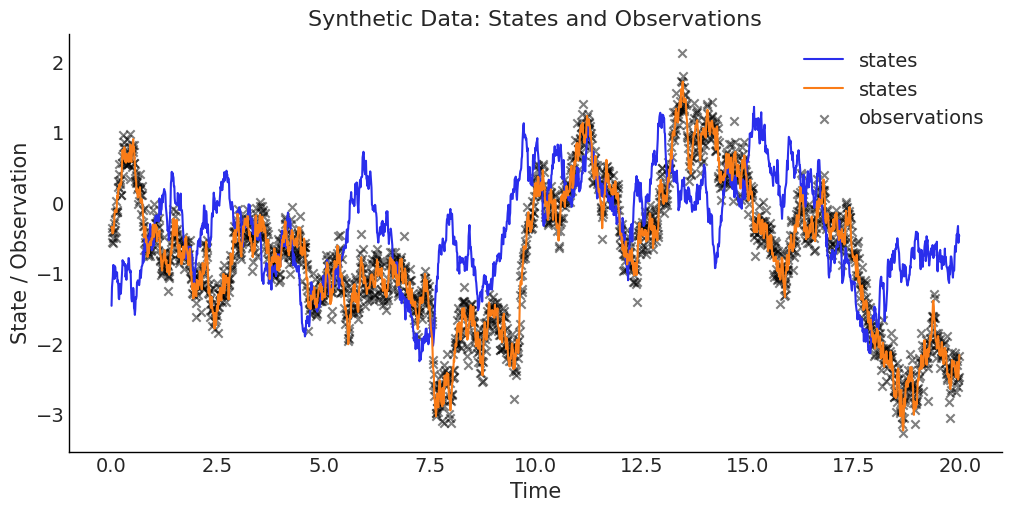

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

plt.plot(synthetic_samples["times"][0], synthetic_samples["states"][0], label="states")
plt.scatter(
    synthetic_samples["times"][0],
    synthetic_samples["observations"][0],
    label="observations",
    marker="x",
    color="black",
    alpha=0.5,
)
plt.title("Synthetic Data: States and Observations")
plt.xlabel("Time")
plt.ylabel("State / Observation")
sns.despine()
plt.legend()
plt.show()

## Bayesian system identification

Performing Bayesian inference for system identification (in this case, obtaining posteriors of $\rho$) also becomes simple. Recall that to obtain posteriors of $\theta$, we must compute posteriors with respect to 

$$ p(\theta \mid y_{1:T}) \propto p(\theta) \underbrace{p(y_{1:T} \mid \theta)}_{\text{marginal likelihod}}. $$

What we'll do is obtain a **data-conditioned model**, that will solve for the marginal likelihood factor using specialized inference methods for dynamical systems; parameter inference over $\theta$ then becomes standard Monte Carlo or variational inference over the data-conditioned model.

To set up a data-conditioned model, pass `obs_times` and `obs_values` directly to the model, wrapped in a `Filter` for marginal likelihood computation.

In [12]:
from dynestyx.filters import (
    Filter,
)

obs_values = synthetic_samples["observations"].squeeze(0)  # shape (T, obs_dim)

def data_conditioned_model():
    with Filter():
        return continuous_time_lti_gaussian_model(obs_times=obs_times, obs_values=obs_values)


The `Filter` object gives us some control over the way we solve for the marginal likelihood, including the method and its hyperparameters. By default, we use an ensemble Kalman filter (EnKF); the EnKF is biased for nonlinear state space models, but still generally accurate for high-quality inference. To change the filtering method, pass a config, e.g. `Filter(filter_config=ContinuousTimeDPFConfig(n_particles=2500))`.

After specifying the marginal likelihood computation, inference can proceed in the standard way for `numpyro` (although, MCMC quality may vary based on what approximation to the marginal likelihood we take). The EnKF provides a very smooth marginal likelkhood, so we can often use NUTS in state space models that are not overly complex. 

In [13]:
from numpyro.infer import MCMC, NUTS

mcmc_key = jr.PRNGKey(0)
nuts_kernel = NUTS(data_conditioned_model)
mcmc = MCMC(nuts_kernel, num_samples=100, num_warmup=100)
mcmc.run(mcmc_key)

posterior_samples = mcmc.get_samples()

sample: 100%|██████████| 200/200 [00:52<00:00,  3.85it/s, 3 steps of size 6.41e-01. acc. prob=0.96]


Plotting the posterior values of $\rho$ shows a posterior centered at the true value of $2.0$.

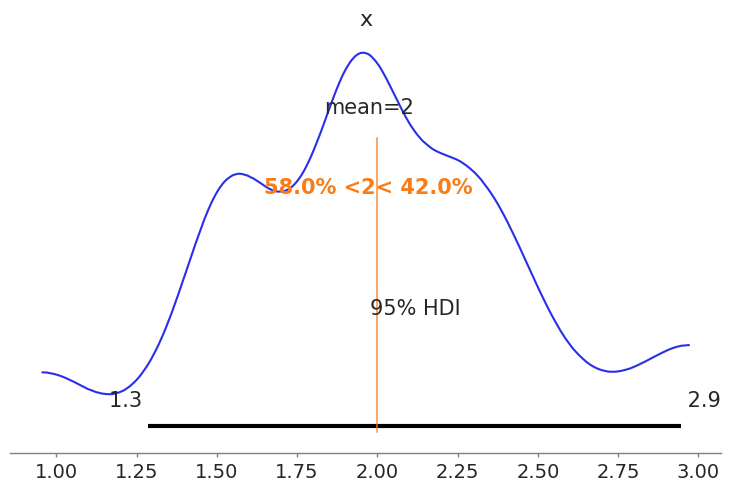

In [14]:
import arviz as az
az.style.use("arviz-white")

az.plot_posterior(
    posterior_samples["rho"], 
    hdi_prob=0.95,
    ref_val=2.0
)

plt.show()